In [1]:
!pip install numpy & pandas
!pip install scikit-learn matplotlib seaborn

'pandas' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv('customer_churn_dataset-training-master.csv')

In [3]:
df_train = df_train.drop('CustomerID',axis=1)

In [4]:
df_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [5]:
df_train.isnull().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [6]:
df_train = df_train.dropna()

In [7]:
df_train.shape

(440832, 11)

In [8]:
df_train.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [9]:
numeric = ['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction','Churn']

corr = df_train[numeric].corr()
corr

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.011630,-0.007190,0.158451,0.061738,-0.084684,0.028980,0.218394
Tenure,-0.011630,1.000000,-0.026800,-0.027640,-0.016588,0.019006,-0.006903,-0.051919
Usage Frequency,-0.007190,-0.026800,1.000000,-0.022013,-0.014470,0.018631,-0.004662,-0.046101
Support Calls,0.158451,-0.027640,-0.022013,1.000000,0.162889,-0.221594,0.077684,0.574267
Payment Delay,0.061738,-0.016588,-0.014470,0.162889,1.000000,-0.121044,0.042708,0.312129
Total Spend,-0.084684,0.019006,0.018631,-0.221594,-0.121044,1.000000,-0.056890,-0.429355
Last Interaction,0.028980,-0.006903,-0.004662,0.077684,0.042708,-0.056890,1.000000,0.149616
Churn,0.218394,-0.051919,-0.046101,0.574267,0.312129,-0.429355,0.149616,1.000000


<Axes: >

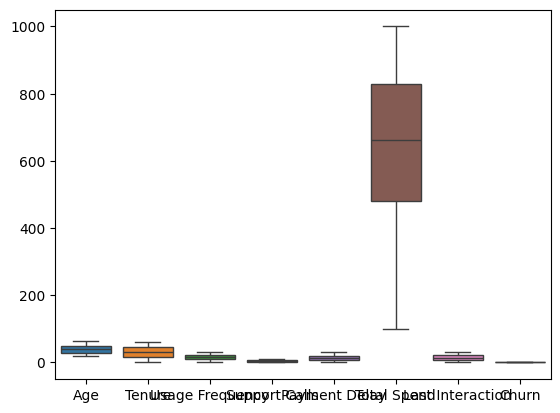

In [10]:
sns.boxplot(df_train[numeric])

In [11]:
outlier_dict={}

for col in numeric:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outlier = df_train[(df_train[col]<lower) | (df_train[col]>upper)]
    outlier_dict = outlier.shape[0]
    print(f"{col} → Outliers: {outlier.shape[0]}")

Age → Outliers: 0
Tenure → Outliers: 0
Usage Frequency → Outliers: 0
Support Calls → Outliers: 0
Payment Delay → Outliers: 0
Total Spend → Outliers: 0
Last Interaction → Outliers: 0
Churn → Outliers: 0


In [12]:
print(df_train.columns)

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')


In [13]:
# One-hot encoding
df_train = pd.get_dummies(df_train, columns=['Subscription Type','Contract Length'], drop_first=True)

# Gender encoding
df_train['Gender'] = df_train['Gender'].map({'Male': 1, 'Female': 0})

In [14]:
df_train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,False,True,False,False
1,65.0,0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,False,False,True,False
2,55.0,0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,False,False,False,True
3,58.0,1,38.0,21.0,7.0,7.0,396.0,29.0,1.0,False,True,True,False
4,23.0,1,32.0,20.0,5.0,8.0,617.0,20.0,1.0,False,False,True,False


In [15]:
# CELL 1 — Model training (imbalance fix ke saath)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
import pickle

X = df_train.drop('Churn', axis=1)
y = df_train['Churn']

print("Churn distribution:", y.value_counts(normalize=True).round(2).to_dict())
# Agar churn > 55% hai to class_weight='balanced' ZAROORI hai

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))  # ← YAHAN CHANGE
])
pipeline.fit(X_train, y_train)

print(classification_report(y_test, pipeline.predict(X_test)))

# DONO files save karo
pickle.dump(pipeline, open('model.pkl', 'wb'))
pickle.dump(list(X_train.columns), open('model_columns.pkl', 'wb'))  # ← NEW FILE
print("Saved! Columns:", list(X_train.columns))

Churn distribution: {1.0: 0.57, 0.0: 0.43}
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.89     47637
         1.0       0.94      0.87      0.91     62571

    accuracy                           0.90    110208
   macro avg       0.89      0.90      0.90    110208
weighted avg       0.90      0.90      0.90    110208

Saved! Columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


In [16]:
print(X_train.columns)

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Total Spend', 'Last Interaction',
       'Subscription Type_Premium', 'Subscription Type_Standard',
       'Contract Length_Monthly', 'Contract Length_Quarterly'],
      dtype='object')


In [20]:
# CELL 2 — Test prediction (correct tarika)
import pickle, pandas as pd

pipeline = pickle.load(open('model.pkl', 'rb'))
model_columns = pickle.load(open('model_columns.pkl', 'rb'))

def predict_churn(age, gender, tenure, usage_freq, support_calls,
                  payment_delay, total_spend, last_interaction, sub_type, contract):
    raw = {
        'Age': age, 'Gender': gender, 'Tenure': tenure,
        'Usage Frequency': usage_freq, 'Support Calls': support_calls,
        'Payment Delay': payment_delay, 'Total Spend': total_spend,
        'Last Interaction': last_interaction,
        'Subscription Type': sub_type, 'Contract Length': contract
    }
    df_in = pd.DataFrame([raw])
    df_in['Gender'] = df_in['Gender'].map({'Male': 1, 'Female': 0})
    df_in = pd.get_dummies(df_in, columns=['Subscription Type','Contract Length'], drop_first=True)
    for col in model_columns:
        if col not in df_in.columns:
            df_in[col] = 0
    df_in = df_in[model_columns]
    pred = pipeline.predict(df_in)[0]
    proba = pipeline.predict_proba(df_in)[0][1]
    print(f"Result: {'🔴 CHURN' if pred==1 else '🟢 NO CHURN'} | Probability: {proba:.1%}")

# Test karo
predict_churn(57, 'Female', 46, 30, 2, 21, 705, 5, 'Standard', 'Annual')   # Low risk
predict_churn(27, 'Female', 44, 21, 3, 22, 515, 1, 'Premium', 'Annual')   # High risk


Result: 🔴 CHURN | Probability: 51.2%
Result: 🔴 CHURN | Probability: 72.6%


In [16]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# X = df_train.drop('Churn', axis=1)
# y = df_train['Churn']

# # Split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# # Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train_scaled, y_train)

# y_pred = model.predict(X_test_scaled)
# y_pred_train = model.predict(X_train_scaled)


# print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
# print("Test Accuracy :", accuracy_score(y_test, y_pred))


Train Accuracy: 0.8951860723964382
Test Accuracy : 0.8961055458768873
